In [1]:
!pip install transformers==4.37.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.9 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.0
    Uninstalling tokenizers-0.21.0:
      Successfully uninstalled tokenizers-0.21.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.47.1
    Uninstalling transformers-4.47.1:
      Successfully uninstalled transformers-4.47.1


In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from transformers import BertTokenizer, TFBertModel

import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split


In [3]:
os.environ["WANDB_API_KEY"] = "0" ## to silence warning

In [4]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy() # for CPU and single GPU
    print('Number of replicas:', strategy.num_replicas_in_sync)

In [5]:
# hyperparameters
max_length = 128
batch_size = 32
dev_size = 0.25

In [6]:
# Bert Tokenizer
model_name = "bert-base-multilingual-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/872k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

In [7]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/shashank_paper_2/Hindi/Hindi_Depression.csv")
train_df.head()
#train_df = pd.read_excel('/content/drive/MyDrive/paper_5/Experiment with Hindi Dataset/list_hinglish.xlsx', names = ['CM', 'Hindi', 'label'])

,S. No.,text,label
0,0,मेरी सबसे बड़ी समस्या हर चीज़ पर बहुत ज़्यादा ...,1
1,1,सबसे बुरा दुःख वह दुःख है जिसे आपने स्वयं छिपा...,1
2,2,मैं पहले से ही जानता हूं कि मैं काफी अच्छा नही...,1
3,3,"मैं अब पहले जैसा नहीं रहा। मैं मानता हूँ, बहुत...",1
4,4,"मेरे मन में बहुत कुछ चल रहा है, लेकिन मैं अंत ...",1


In [8]:
train_df.tail()

,S. No.,text,label
12024,4995,काइली जेनर ने अपने नवीनतम फोटो शूट में विशाल स...,0
12025,4996,ट्रम्प ने यौन उत्पीड़न के आरोपियों पर मुकदमा च...,0
12026,4997,हफ़पोस्ट ने अमन सेठी को भारत का प्रधान संपादक ...,0
12027,4998,लाइव देखें: संयुक्त राष्ट्र मुख्यालय में समाधा...,0
12028,4999,सेरेना विलियम्स ने फोन चोर को पकड़ने के लिए अप...,0


In [9]:
train, dev = train_test_split(train_df, test_size=dev_size, random_state=42)

In [10]:
dev

,S. No.,text,label
4412,4412,मुझे लगता है कि अभिनय के अलावा मैं एक सामान्य ...,0
10471,3442,ओक्लाहोमा सिटी पुलिस द्वारा गोली मारकर हत्या क...,0
5032,5032,मुझे काम में व्यस्त होने जैसा अभिनय करने के लि...,0
2611,2611,“मैं तब तक सोना चाहता हूँ जब तक मैं बेहतर महसू...,1
1562,1562,अपने आप से प्यार करना याद रखें,0
...,...,...,...
6760,6760,कुछ लोग बहुत ज़्यादा परवाह करते हैं। मुझे लगता...,1
10053,3024,पवित्र गुआकामोल! न्यूज़ीलैंड में लोग एवोकाडो च...,0
5493,5493,"हम दोनों ने कहा ""मैं तुमसे प्यार करता हूँ"" लेक...",1
5826,5826,आलोचनात्मक समाज ही वह मुख्य कारण है जिसके कारण...,1


In [11]:
def bert_encode(data):
    tokens = tokenizer.batch_encode_plus(data, max_length=max_length, padding='max_length', truncation=True)

    return tf.constant(tokens['input_ids'])

In [12]:
train_encoded = bert_encode(train.text)
dev_encoded = bert_encode(dev.text)


train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((train_encoded, train.label))
    .shuffle(100)
    .batch(batch_size)
)

dev_dataset = (
    tf.data.Dataset
    .from_tensor_slices((dev_encoded, dev.label))
    .shuffle(100)
    .batch(batch_size)
)

In [13]:
import tensorflow as tf
from transformers import BertTokenizer, TFBertModel

class BahdanauAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features shape == (batch_size, max_length, hidden_size)
        # hidden shape == (batch_size, hidden_size)

        # Expand the hidden shape to match the shape of features
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # Calculate attention scores
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))

        # Apply V to get attention weights
        attention_weights = tf.nn.softmax(self.V(score), axis=1)

        # Compute the context vector
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

def lstm_with_attention_model():
    # Load the BERT model
    bert_encoder = TFBertModel.from_pretrained(model_name)

    # Define input layer for BERT
    input_word_ids = tf.keras.Input(shape=(max_length,), dtype=tf.int32, name="input_ids")

    # Get BERT embeddings
    bert_output = bert_encoder(input_word_ids)[0]  # Extract BERT embeddings

    # Define the LSTM layer with return_sequences=True to output sequences
    lstm_layer = tf.keras.layers.LSTM(100, return_sequences=True)
    lstm_output = lstm_layer(bert_output)

    # Apply attention mechanism
    attention_layer = BahdanauAttention(units=100)
    context_vector, attention_weights = attention_layer(lstm_output, lstm_output[:, -1, :])  # Use last hidden state as query

    # Add output layer
    output = tf.keras.layers.Dense(1, activation='sigmoid')(context_vector)

    # Define the model
    model = tf.keras.Model(inputs=input_word_ids, outputs=output)

    return model

# Initialize the model
with strategy.scope():
    model = lstm_with_attention_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])

# Print model summary
model.summary()


/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/672M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 tf_bert_model (TFBertModel  TFBaseModelOutputWithPooli   1673564   ['input_ids[0][0]']           
 )                           ngAndCrossAttentions(last_   16                                      
                             hidden_state=(None, 128, 7                                           
                             68),                                                                 
                              pooler_output=(None, 768)                                           
                             , past_key_values=None, hi                                       

In [14]:
train_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 128), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [15]:
#from keras.utils.vis_utils import plot_model
with strategy.scope():
    model = lstm_with_attention_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy',optimizer=adam_optimizer,metrics=['accuracy'])

    model.summary()
    #plot_model(model=model, show_shapes=True)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 tf_bert_model_1 (TFBertMod  TFBaseModelOutputWithPooli   1673564   ['input_ids[0][0]']           
 el)                         ngAndCrossAttentions(last_   16                                      
                             hidden_state=(None, 128, 7                                           
                             68),                                                                 
                              pooler_output=(None, 768)                                           
                             , past_key_values=None, hi                                     

In [16]:
history = model.fit(
    train_dataset,
    batch_size=batch_size,
    epochs=3,
    validation_data=dev_dataset,
    verbose=2)
    #callbacks=[tf.keras.callbacks.EarlyStopping(
    #            patience=6,
    #            min_delta=0.05,
    #            baseline=0.7,
    #            mode='min',
    #            monitor='val_accuracy',
    #            restore_best_weights=True,
    #            verbose=1)
    #          ])

Epoch 1/3


282/282 - 144s - loss: 0.3570 - accuracy: 0.8237 - val_loss: 0.2674 - val_accuracy: 0.8873 - 144s/epoch - 509ms/step
Epoch 2/3
282/282 - 34s - loss: 0.2354 - accuracy: 0.9023 - val_loss: 0.2333 - val_accuracy: 0.9023 - 34s/epoch - 120ms/step
Epoch 3/3
282/282 - 34s - loss: 0.1903 - accuracy: 0.9234 - val_loss: 0.2363 - val_accuracy: 0.9053 - 34s/epoch - 120ms/step


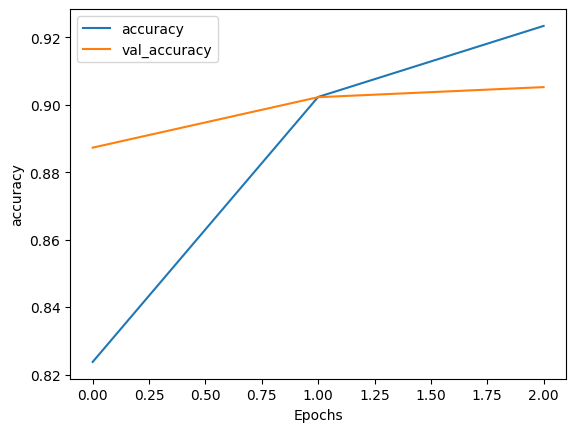

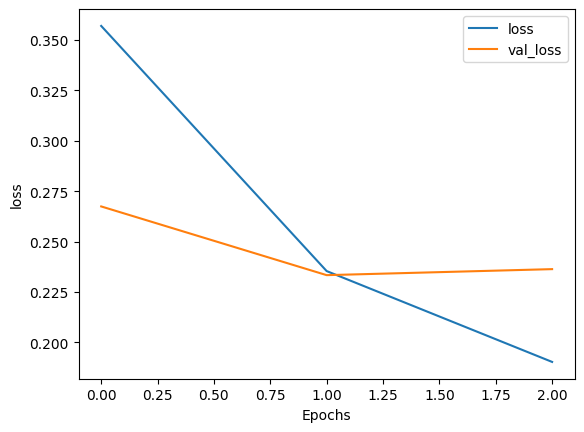

In [17]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [18]:
test, val = train_test_split(dev, test_size=dev_size, random_state=42)

In [19]:
dev.shape

(3008, 3)

In [20]:
test.head()

,S. No.,text,label
8373,1344,रिपोर्टर के बेतुके सवाल पर अमेरिका फेरेरा का ज...,0
11380,4351,जीवाश्म ईंधन को बढ़ावा देने वाले 7 मिथकों को ध...,0
9656,2627,लिंडसे ग्राहम ने ट्रंप को चेतावनी दी: म्यूएलर ...,0
373,373,नजरिया बदलो और पूरी स्थिति बदल जाएगी।,1
2507,2507,मुझे याद करना जब मै चला जाऊँ,1


In [21]:
test_encoded = bert_encode(dev.text)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(test_encoded)
    .batch(batch_size)
)

predicted_tweets = model.predict(test_dataset, batch_size=batch_size)
predicted_tweets_binary = tf.cast(tf.round(predicted_tweets), tf.int32).numpy().flatten()
print(predicted_tweets_binary)
#my_submission = pd.DataFrame({'id': dev.id, 'label': predicted_tweets_binary})
#my_submission.to_csv('my_submission.csv', index=False)

94/94 [==============================] - 18s 22ms/step
[0 0 0 ... 1 1 0]


In [22]:
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [23]:
print("Bert+LSTM")
print("Accuracy score =", accuracy_score(dev['label'], predicted_tweets_binary))
print(metrics.classification_report(dev['label'], predicted_tweets_binary))


Bert+LSTM
Accuracy score = 0.9052526595744681
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1811
           1       0.87      0.90      0.88      1197

    accuracy                           0.91      3008
   macro avg       0.90      0.90      0.90      3008
weighted avg       0.91      0.91      0.91      3008



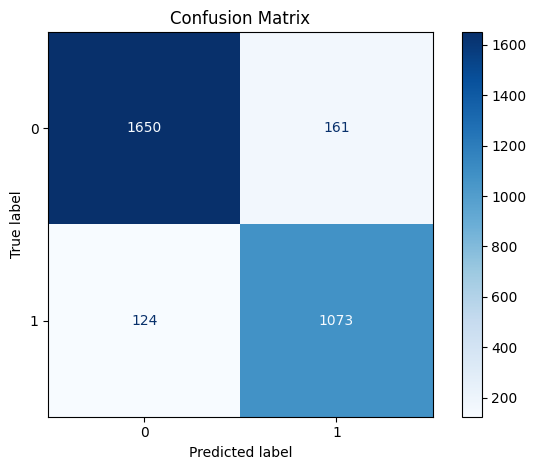

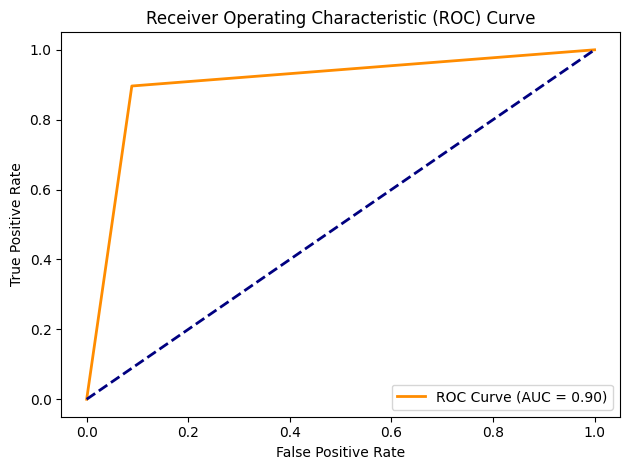

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    RocCurveDisplay,
    precision_recall_curve,
    PrecisionRecallDisplay,
)

# Sample true labels and predicted probabilities
# Replace these with your actual data
#y_true = np.array([0, 1, 1, 0, 1, 0, 1, 1, 0, 0])
#y_pred_proba = np.array([0.1, 0.8, 0.9, 0.3, 0.7, 0.2, 0.85, 0.9, 0.4, 0.5])
#y_pred = (y_pred_proba >= 0.5).astype(int)

# Plot Confusion Matrix
cm = confusion_matrix(dev['label'], predicted_tweets_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
#plt.savefig('/content/drive/MyDrive/shashank_paper_2/Hindi//confusion_h_bert-cnn.pdf', format="pdf")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(dev['label'], predicted_tweets_binary)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.tight_layout()
plt.legend(loc="lower right")
plt.show()
#plt.savefig('/content/drive/MyDrive/shashank_paper_2/Hindi//roc_h_bert-cnn.pdf', format="pdf")
